In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [4]:
df = pd.read_csv("Iris.csv")

In [5]:
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Features and target
X = df.drop('Species', axis=1)
y = df['Species']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [9]:
# Prediction
y_pred = knn.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

Accuracy: 1.0


In [10]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn.classes_
)

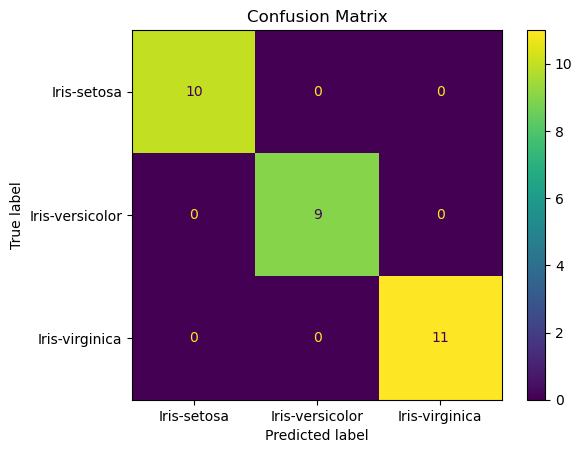

In [11]:
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [12]:
k_values = range(1, 21)
acc = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    acc.append(accuracy_score(y_test, pred))


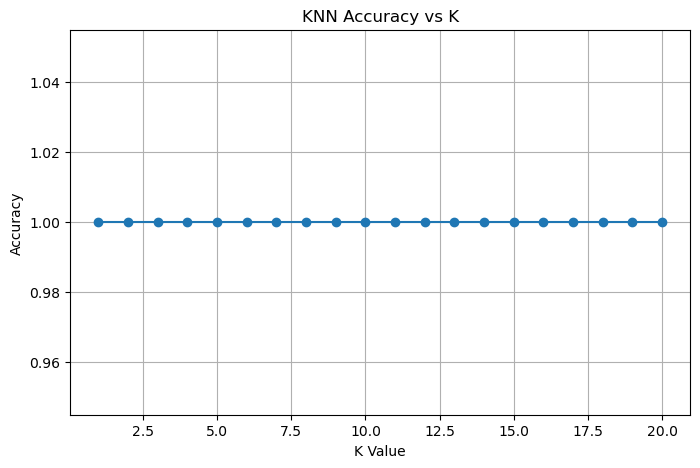

In [13]:
plt.figure(figsize=(8,5))
plt.plot(k_values, acc, marker='o')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K')
plt.grid(True)
plt.show()

In [14]:
best_k = k_values[np.argmax(acc)]
print("Best K =", best_k)
print("Best Accuracy =", max(acc))

Best K = 1
Best Accuracy = 1.0
